In [1]:
import numpy as np
import finufft
import matplotlib.pyplot as pl
import time
tic = time.time()

pi = np.pi
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

f_max = 200
f_strobo = 40*f_max
f_nufft = 3*f_max

def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

def strobo(beta, data, t, f_new=f_strobo/20):
    new_t = -3/5*(1-8/3*beta*t)**(5/8)/beta
    new_t *= f_new 
    floor_t = np.floor(new_t) 
    idx = np.nonzero(np.diff(floor_t))
    resampled = data[idx]
    t_out = (new_t[idx]-new_t[0])/f_new
#     print(f_new)
#     print(t_out)
    corrected = np.fft.fftshift(np.fft.fft(resampled))
    strobo_freq = np.fft.fftshift(np.fft.fftfreq(len(t_out), d=t_out[1]-t_out[0]))
    strobo_power = np.abs(corrected/len(resampled))**2
    return (strobo_freq, strobo_power)

def nufft(beta, data, t, bin_no):
    bins = np.arange(bin_no) - bin_no//2
    
    tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
    scale = (2*pi)/(tau[-1]-tau[0])
    tau *= scale
    start_diff = -pi-tau[0]
    tau += start_diff
    nufft_amp = finufft.nufft1d1(tau.astype(np.float64), data.astype(complex), bin_no)
    nufft_freq = bins*scale/(2*pi)
    nufft_power = np.abs(nufft_amp/len(data))**2
    return nufft_freq, nufft_power


In [13]:
f = 20
M = 1e-1 * 2e30
f_nufft = 3*f_max

In [14]:
beta = const*f**(8/3)*M**(5/3)
T_obs = min(1e4, t_max_calc(f, beta, 200))

#Creating the signal
t_strobo = np.arange(0, T_obs, 1/f_strobo).astype(np.longdouble)
phi = -6*pi/5*f*(1-8./3.*(beta)*t_strobo)**(5/8)/beta
phi = np.mod(phi,2*pi)
signal_strobo = 1*np.exp(1j*phi)
signal_strobo[:int(1e3)] = np.zeros((int(1e3)))
signal_strobo[-int(1e3):] = np.zeros((int(1e3)))

t_nufft = np.arange(0, T_obs, 1/f_nufft).astype(np.longdouble)
phi = -6*pi/5*f*(1-8./3.*(beta)*t_nufft)**(5/8)/beta
phi = np.mod(phi,2*pi)
signal_nufft = 1*np.exp(1j*phi)
signal_nufft[:int(1e3)] = np.zeros((int(1e3)))
signal_nufft[-int(1e3):] = np.zeros((int(1e3)))

tic = time.time()
strobo_freq, strobo_power = strobo(beta, signal_strobo, t_strobo, f_new=f_strobo/25)
strobo_time = (time.time() - tic)/60

tic=time.time()
nufft_freq, nufft_power = nufft(beta, signal_nufft, t_nufft, len(signal_nufft))
nufft_time = (time.time() - tic)/60

strobo_peak = strobo_power>np.median(strobo_power)+6*np.std(strobo_power)
nufft_peak = nufft_power>np.median(nufft_power)+6*np.std(nufft_power)

nufft_info={'name':'nufft',
            'inj_freq':f,
            'inj_mass':M,
            'power':np.sum(nufft_power[nufft_peak]),
            'peak_f':nufft_freq[np.argmax(nufft_power)],
            'time': nufft_time}

strobo_info={'name':'strobo',
             'inj_freq':f,
             'inj_mass':M,
             'power':np.sum(strobo_power[strobo_peak]),
             'peak_f':strobo_freq[np.argmax(strobo_power)],
             'time':strobo_time}

In [20]:
T_obs*f_nufft

6000000.0

In [16]:
nufft_info['power']

1.0886275991011407

In [17]:
# pl.plot(signal_strobo)
# pl.ylim(0.98, 1.001)

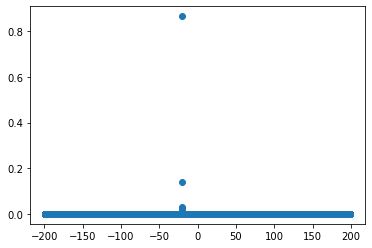

In [18]:
pl.plot(nufft_freq, nufft_power, 'o')
# pl.xlim(19.95, 20.05)

<>:13: DeprecationWarning: invalid escape sequence \s
<>:13: DeprecationWarning: invalid escape sequence \s
<>:13: DeprecationWarning: invalid escape sequence \s
/tmp/ipykernel_178040/816984543.py:13: DeprecationWarning: invalid escape sequence \s
  only showing points 6$\sigma$ above median")


Text(0.5, 1.0, 'Comparing strobo and nufft results: \n f=20, Mc=1e-1, \n only showing points 6$\\sigma$ above median')

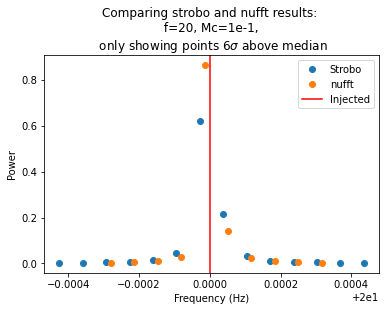

In [19]:
strobo_peak = strobo_power>np.median(strobo_power)+6*np.std(strobo_power)
nufft_peak = nufft_power>np.median(nufft_power)+6*np.std(nufft_power)

pl.plot(strobo_freq[strobo_peak], strobo_power[strobo_peak], 'o', label='Strobo')
pl.plot(-nufft_freq[nufft_peak], nufft_power[nufft_peak], 'o', label='nufft')
pl.axvline(20, c='r', label='Injected')
# pl.plot(nufft_freq[np.argmax(nufft_power)-1], nufft_power[np.argmax(nufft_power)-1], 'go')
# pl.xlim(19.9995, 20.0005)
pl.ylabel("Power")
pl.xlabel("Frequency (Hz)")
pl.legend()
pl.title("Comparing strobo and nufft results: \n f=20, Mc=1e-1, \n \
only showing points 6$\sigma$ above median")